# Data Analysis for Option 1 Results

In [887]:
import pandas as pd
import numpy 

endpoint = "chr-liver"

full_df = pd.read_csv(f"../references/full_print_results/{endpoint}/big_results_percentages.csv")
full_df = full_df.drop(columns = {"Unnamed: 0"})

In [888]:
full_df[['param_hybrid_weights','split0_test_accuracy',
       'split1_test_accuracy', 'split2_test_accuracy', 'split3_test_accuracy',
       'split4_test_accuracy', 'mean_test_accuracy', 'std_test_accuracy']].head(10)

,param_hybrid_weights,split0_test_accuracy,split1_test_accuracy,split2_test_accuracy,split3_test_accuracy,split4_test_accuracy,mean_test_accuracy,std_test_accuracy
0,"[0, 0, 0, 0, 100]",0.787234,0.744681,0.765957,0.774194,0.774194,0.769252,0.014048
1,"[0, 0, 0, 10, 90]",0.787234,0.744681,0.776596,0.774194,0.774194,0.771380,0.014193
2,"[0, 0, 0, 20, 80]",0.787234,0.744681,0.776596,0.774194,0.774194,0.771380,0.014193
3,"[0, 0, 0, 30, 70]",0.787234,0.744681,0.776596,0.774194,0.774194,0.771380,0.014193
4,"[0, 0, 0, 40, 60]",0.776596,0.734043,0.765957,0.763441,0.763441,0.760695,0.014184
5,"[0, 0, 0, 50, 50]",0.765957,0.755319,0.765957,0.763441,0.763441,0.762823,0.003917
6,"[0, 0, 0, 60, 40]",0.765957,0.755319,0.755319,0.763441,0.774194,0.762846,0.007101
7,"[0, 0, 0, 70, 30]",0.744681,0.755319,0.765957,0.763441,0.774194,0.760718,0.010028
8,"[0, 0, 0, 80, 20]",0.765957,0.765957,0.755319,0.774194,0.774194,0.767124,0.006957
9,"[0, 0, 0, 90, 10]",0.765957,0.765957,0.765957,0.784946,0.774194,0.771402,0.007486


In [889]:
#Weights saved as a string for the CSV, so we will fix this (if integer weights)
df = full_df[["param_hybrid_weights", "mean_test_accuracy","mean_test_precision","mean_test_recall", "mean_test_roc_auc"]].sort_values("mean_test_roc_auc", ascending = False) 
df["param_hybrid_weights"] = [ [int(df["param_hybrid_weights"][i][1]), int(df["param_hybrid_weights"][i][4]), int(df["param_hybrid_weights"][i][7]), int(df["param_hybrid_weights"][i][10]), int(df["param_hybrid_weights"][i][13])] for i in range(0, len(df["param_hybrid_weights"]))]
df.head()

ValueError: invalid literal for int() with base 10: ' '

In [912]:
#If percentage weights, we will need this version:
df = full_df[["param_hybrid_weights", "mean_test_accuracy","mean_test_precision","mean_test_recall", "mean_test_roc_auc"]].sort_values("mean_test_roc_auc", ascending = False) 
new_weights = []
for i in df["param_hybrid_weights"]:
    number_list = i.split(",")
    first = number_list[0][1:]
    last = number_list[-1][:-1]
    new_weights.append([int(first), int(number_list[1]), int(number_list[2]), int(number_list[3]), int(last)])
df["param_hybrid_weights"] = new_weights

In [913]:
#Calculate percentage contributions from the weights, as these are often more intuitive
morgan_weight = [df["param_hybrid_weights"][i][1] for i in range(0,len(df["param_hybrid_weights"]))]
toxprint_weight = [df["param_hybrid_weights"][i][0] for i in range(0,len(df["param_hybrid_weights"]))]
torsion_weight = [df["param_hybrid_weights"][i][2] for i in range(0,len(df["param_hybrid_weights"]))]
toxcast_weight = [df["param_hybrid_weights"][i][3] for i in range(0,len(df["param_hybrid_weights"]))]
aims_weight = [df["param_hybrid_weights"][i][4] for i in range(0,len(df["param_hybrid_weights"]))]

df["morgan"] = [morgan_weight[i]/sum(df["param_hybrid_weights"][i]) for i in range(0,len(morgan_weight))]
df["toxprint"] = [toxprint_weight[i]/sum(df["param_hybrid_weights"][i]) for i in range(0,len(toxprint_weight))]
df["torsion"] = [torsion_weight[i]/sum(df["param_hybrid_weights"][i]) for i in range(0,len(torsion_weight))]
df["toxcast"] = [toxcast_weight[i]/sum(df["param_hybrid_weights"][i]) for i in range(0,len(toxcast_weight))]
df["aims"] = [aims_weight[i]/sum(df["param_hybrid_weights"][i]) for i in range(0,len(aims_weight))]


In [914]:
df = df.sort_values("mean_test_accuracy", ascending = False).drop(columns = {"param_hybrid_weights"})
df.head()

,mean_test_accuracy,mean_test_precision,mean_test_recall,mean_test_roc_auc,morgan,toxprint,torsion,toxcast,aims
10,0.784168,0.784441,0.994521,0.591210,0.4,0.5,0.0,0.0,0.1
92,0.779913,0.782219,0.991781,0.631892,0.0,0.1,0.7,0.0,0.2
28,0.779913,0.782168,0.991781,0.636843,0.6,0.0,0.0,0.2,0.2
37,0.779890,0.779747,0.997260,0.635742,0.7,0.0,0.1,0.0,0.2
817,0.779890,0.779734,0.997260,0.608321,0.5,0.3,0.2,0.0,0.0


In [940]:
df["morgan"]

10     0.4
92     0.0
28     0.6
37     0.7
817    0.5
      ... 
678    0.2
859    0.1
739    0.0
685    0.1
719    0.5
Name: morgan, Length: 1001, dtype: float64

## Top/Bottom DataFrame Creation
 There are many, many results for this data set, so let's look only at the best and worst in each category to examine patterns as well. 

In [893]:
accuracy_df1 = df.sort_values("mean_test_accuracy").iloc[0:10, :]
accuracy_df2 = df.sort_values("mean_test_accuracy").iloc[-10:, :]
accuracy_df3 = df.sort_values("mean_test_accuracy").iloc[495:505, :]
accuracy_df = pd.concat([accuracy_df1, accuracy_df2, accuracy_df3]).sort_values("mean_test_accuracy", ascending = False)
accuracy_df.head(10)

,mean_test_accuracy,mean_test_precision,mean_test_recall,mean_test_roc_auc,morgan,toxprint,torsion,toxcast,aims
10,0.784168,0.784441,0.994521,0.591210,0.4,0.5,0.0,0.0,0.1
92,0.779913,0.782219,0.991781,0.631892,0.0,0.1,0.7,0.0,0.2
28,0.779913,0.782168,0.991781,0.636843,0.6,0.0,0.0,0.2,0.2
37,0.779890,0.779747,0.997260,0.635742,0.7,0.0,0.1,0.0,0.2
817,0.779890,0.779734,0.997260,0.608321,0.5,0.3,0.2,0.0,0.0
91,0.777785,0.779280,0.994521,0.628845,0.2,0.1,0.3,0.3,0.1
459,0.777763,0.780560,0.991781,0.622917,0.0,0.2,0.4,0.2,0.2
162,0.777763,0.779280,0.994521,0.595363,0.1,0.5,0.1,0.0,0.3
247,0.777763,0.779391,0.994521,0.594026,0.1,0.5,0.2,0.2,0.0
165,0.777763,0.778050,0.997222,0.588056,0.0,0.6,0.2,0.0,0.2


In [894]:
precision_df1 = df.sort_values("mean_test_precision").iloc[0:10, :]
precision_df2 = df.sort_values("mean_test_precision").iloc[-10:, :]
precision_df3 = df.sort_values("mean_test_precision").iloc[495:505, :]
precision_df = pd.concat([precision_df1, precision_df2, precision_df3]).sort_values("mean_test_precision", ascending = False)
precision_df.head(10)

,mean_test_accuracy,mean_test_precision,mean_test_recall,mean_test_roc_auc,morgan,toxprint,torsion,toxcast,aims
10,0.784168,0.784441,0.994521,0.591210,0.4,0.5,0.0,0.0,0.1
92,0.779913,0.782219,0.991781,0.631892,0.0,0.1,0.7,0.0,0.2
28,0.779913,0.782168,0.991781,0.636843,0.6,0.0,0.0,0.2,0.2
164,0.775612,0.781237,0.986187,0.573157,0.0,0.8,0.0,0.2,0.0
19,0.775635,0.781237,0.986225,0.641629,0.3,0.0,0.2,0.3,0.2
129,0.773530,0.780806,0.983562,0.616847,0.5,0.2,0.1,0.2,0.0
84,0.773530,0.780789,0.983524,0.624347,0.0,0.2,0.0,0.1,0.7
280,0.773507,0.780776,0.983486,0.636725,0.6,0.0,0.0,0.3,0.1
459,0.777763,0.780560,0.991781,0.622917,0.0,0.2,0.4,0.2,0.2
862,0.771357,0.780515,0.980708,0.642390,0.3,0.0,0.0,0.2,0.5


In [895]:
recall_df1 = df.sort_values("mean_test_recall").iloc[0:10, :]
recall_df2 = df.sort_values("mean_test_recall").iloc[-10:, :]
recall_df3 = df.sort_values("mean_test_recall").iloc[495:505, :]
recall_df = pd.concat([recall_df1, recall_df2, recall_df3]).sort_values("mean_test_recall", ascending = False)
recall_df.head(10)

,mean_test_accuracy,mean_test_precision,mean_test_recall,mean_test_roc_auc,morgan,toxprint,torsion,toxcast,aims
817,0.779890,0.779734,0.997260,0.608321,0.5,0.3,0.2,0.0,0.0
37,0.779890,0.779747,0.997260,0.635742,0.7,0.0,0.1,0.0,0.2
165,0.777763,0.778050,0.997222,0.588056,0.0,0.6,0.2,0.0,0.2
10,0.784168,0.784441,0.994521,0.591210,0.4,0.5,0.0,0.0,0.1
212,0.773507,0.775853,0.994521,0.629562,0.2,0.1,0.0,0.3,0.4
184,0.773507,0.775853,0.994521,0.622748,0.0,0.2,0.4,0.4,0.0
26,0.771380,0.774183,0.994521,0.640581,0.3,0.0,0.4,0.2,0.1
44,0.775635,0.777597,0.994521,0.628905,0.2,0.1,0.3,0.1,0.3
27,0.771380,0.774229,0.994521,0.631974,0.0,0.1,0.6,0.3,0.0
162,0.777763,0.779280,0.994521,0.595363,0.1,0.5,0.1,0.0,0.3


In [896]:
roc_df1 = df.sort_values("mean_test_roc_auc").iloc[0:10, :]
roc_df2 = df.sort_values("mean_test_roc_auc").iloc[-10:, :]
roc_df3 = df.sort_values("mean_test_roc_auc").iloc[495:505, :]
roc_df = pd.concat([roc_df1, roc_df2, roc_df3]).sort_values("mean_test_roc_auc", ascending=False)
roc_df.head(10)

,mean_test_accuracy,mean_test_precision,mean_test_recall,mean_test_roc_auc,morgan,toxprint,torsion,toxcast,aims
573,0.767124,0.774393,0.986263,0.675784,0.0,0.0,0.0,0.0,1.0
725,0.767101,0.775574,0.983447,0.671176,0.0,0.0,0.0,0.1,0.9
687,0.764997,0.775099,0.980746,0.670995,0.0,0.0,0.0,0.2,0.8
765,0.769229,0.777318,0.983447,0.670987,0.0,0.0,0.0,0.3,0.7
776,0.762823,0.777239,0.972451,0.670125,0.0,0.0,0.0,0.4,0.6
746,0.769252,0.776113,0.986263,0.669887,0.0,0.0,0.0,0.5,0.5
771,0.771380,0.776604,0.989041,0.668651,0.0,0.0,0.0,0.6,0.4
626,0.769229,0.777318,0.983447,0.668553,0.0,0.0,0.0,0.7,0.3
750,0.764974,0.776429,0.977968,0.668369,0.0,0.0,0.0,0.8,0.2
715,0.762846,0.774645,0.978006,0.668101,0.0,0.0,0.0,0.9,0.1


## Graph Generation

In [1003]:
#Master test variable settings, for generating graphs with given settings from all cells
test_variables = {"x":"aims", "y":"accuracy", "c":"aims"}

### Stratified Graphs

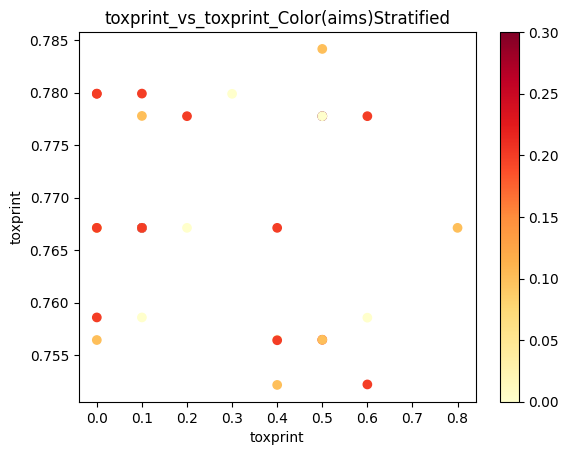

In [ ]:
import matplotlib.pyplot as plt

#View and save results as scatterplot to analyze for trends. Note that most relations do not 
# appear to be linear, so such a regression may not be the best choice

#Accuracy strata
test_variables["y"] = "toxprint"
plt.scatter(x = accuracy_df[test_variables["x"]], y= accuracy_df["mean_test_accuracy"], c= accuracy_df[test_variables["c"]], cmap = "YlOrRd")
plt.colorbar()
plt.xlabel(test_variables["x"])
plt.ylabel(test_variables["y"])
title = f"{test_variables["x"]}_vs_{test_variables["y"]}_Color({test_variables["c"]})Stratified"
plt.title(title)
plt.savefig(f"../references/full_print_results/{endpoint}/strat_graphs/{title}_scatter.png")
plt.show()

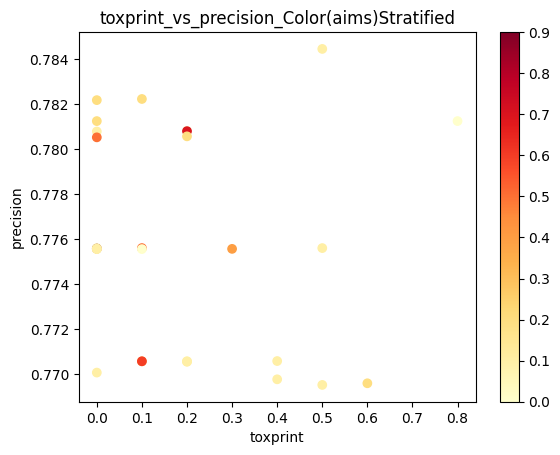

In [ ]:
#Precision strata
test_variables["y"] = "precision"
plt.scatter(x = precision_df[test_variables["x"]], y= precision_df["mean_test_precision"], c= precision_df[test_variables["c"]], cmap = "YlOrRd")
plt.colorbar()
plt.xlabel(test_variables["x"])
plt.ylabel(test_variables["y"])
title = f"{test_variables["x"]}_vs_{test_variables["y"]}_Color({test_variables["c"]})Stratified"
plt.title(title)
plt.savefig(f"../references/full_print_results/{endpoint}/strat_graphs/{title}_scatter.png")
plt.show()

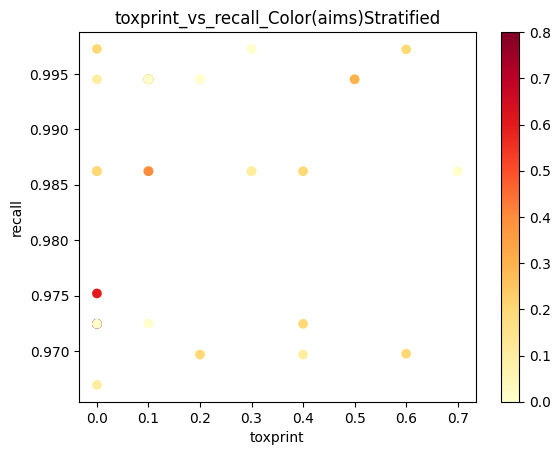

In [ ]:
#Recall strata
test_variables["y"] = "recall"
plt.scatter(x = recall_df[test_variables["x"]], y= recall_df["mean_test_recall"], c= recall_df[test_variables["c"]], cmap = "YlOrRd")
plt.colorbar()
plt.xlabel(test_variables["x"])
plt.ylabel(test_variables["y"])
title = f"{test_variables["x"]}_vs_{test_variables["y"]}_Color({test_variables["c"]})Stratified"
plt.title(title)
plt.savefig(f"../references/full_print_results/{endpoint}/strat_graphs/{title}_scatter.png")
plt.show()

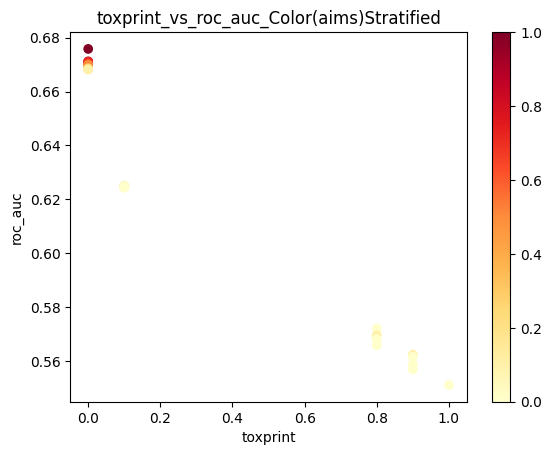

In [ ]:
#ROC strata
test_variables["y"] = "roc_auc"
plt.scatter(x = roc_df[test_variables["x"]], y= roc_df["mean_test_roc_auc"], c= roc_df[test_variables["c"]], cmap = "YlOrRd")
plt.colorbar()
plt.xlabel(test_variables["x"])
plt.ylabel(test_variables["y"])
title = f"{test_variables["x"]}_vs_{test_variables["y"]}_Color({test_variables["c"]})Stratified"
plt.title(title)
plt.savefig(f"../references/full_print_results/{endpoint}/strat_graphs/{title}_scatter.png")
plt.show()

### Full data graph

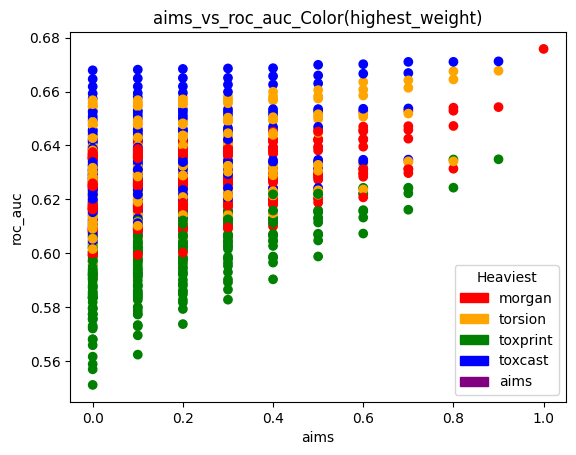

In [1007]:
#Full data set comparisons
import matplotlib.patches as mpatches

df = df.reset_index(drop=True)
test_variables["y"] = "roc_auc"

color_map = {"morgan":"red", "torsion":"orange", "toxprint":"green", "toxcast":"blue", "aims":"purple"}
color_list = []
for i in range(0,len(df)):
    measures = {"morgan":df["morgan"][i], "torsion":df["torsion"][i], "toxprint":df["toxprint"][i], "toxcast":df["toxcast"][i], "aims":df["aims"][i]}
    measures.pop(test_variables['x'])
    max_spot = list(measures.values()).index(max(measures.values()))
    color_list.append(color_map[list(measures.keys())[max_spot]])

plt.scatter(x = df[test_variables["x"]], y= df[f"mean_test_{test_variables["y"]}"], c= color_list)
plt.xlabel(test_variables["x"])
plt.ylabel(test_variables["y"])
legend = [mpatches.Patch(color = value, label = key) for key, value in color_map.items()]
title = f"{test_variables["x"]}_vs_{test_variables["y"]}_Color(highest_weight)"
plt.title(title)
plt.legend(title = "Heaviest", handles = legend)
plt.savefig(f"../references/full_print_results/{endpoint}/full_scatters/{title}_scatter.png")
plt.show()

### Regression-Ready Graphs 
These first two were visually informative when we worked with the four_print_results, but became overloaded in some areas and underloaded in others when the many extra tests of the full results were introduced. A reworked attempt can be seen below. 

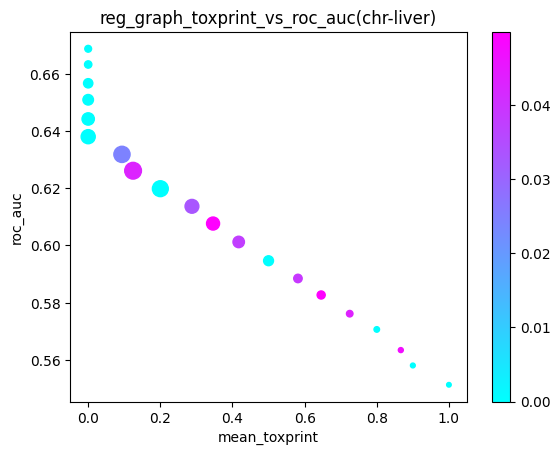

In [878]:
from numpy import arange
from statistics import mean

#Plot average weight of a given fingerprint against the average score in a given neighborhood, this could
#allow for regression analysis of the relation between fingerprint weight and scores
score = "roc_auc"
weight = test_variables["x"]

averages = {score:[], weight: [], "size":[], "std": [] }
minimum = min(df[f"mean_test_{score}"])
maximum = max(df[f"mean_test_{score}"])
data_range = maximum -minimum

for i in arange(minimum, maximum, data_range/20):
    selection = df.loc[(df[f"mean_test_{score}"] < i+data_range/40) & (df[f"mean_test_{score}"] >= i-data_range/40)]
    selection_weight = selection[weight]
    selection_score = selection[f"mean_test_{score}"]
    if len(selection) > 0:
        avg_weight = mean(selection_weight)
        avg_score = mean(selection_score)
        averages[score].append(avg_score)
        averages[weight].append(avg_weight)
        averages["size"].append(len(selection))
        averages["std"].append(numpy.std(selection_weight))

avg_df = pd.DataFrame(averages)

#Color bar will show how many data points from the main data frame contribute to each plotted point 
#to demonstrate some estimate of confidence
plt.scatter(x = avg_df[weight], y = avg_df[score], c = avg_df["std"], cmap = "cool", s = avg_df["size"]+10)
plt.colorbar()
plt.xlabel("mean_"+weight)
plt.ylabel(score)
title = f"reg_graph_{weight}_vs_{score}({endpoint})"
plt.title(title)
plt.savefig(f"../references/full_print_results/{endpoint}/reg1_graphs/{title}.png")
plt.show()

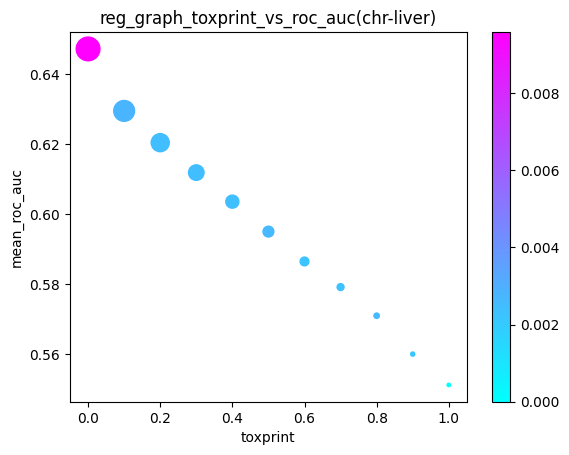

In [879]:
#For each possible weight of a fingerprint, plot average performance by score
score = "roc_auc"
weight = test_variables["x"]

averages = {score:[], weight: [], "size":[], "std":[] }

#For int weights: arange step = 0.03. For percent weights: arange step = 0.1

for i in arange(0,1.1, 0.1):
    selection = df.loc[(df[weight] < i+0.05) & (df[weight] >= i-0.05)]
    selection_weight = selection[weight]
    selection_score = selection[f"mean_test_{score}"]
    if len(selection) > 0:
        avg_weight = mean(selection_weight)
        avg_score = mean(selection_score)
        averages[score].append(avg_score)
        averages[weight].append(avg_weight)
        averages["size"].append(len(selection))
        averages["std"].append(numpy.std(selection_score))

avg_df = pd.DataFrame(averages)

#Color bar will show how many data points from the main data frame contribute to each plotted point 
#to demonstrate some estimate of confidence
plt.scatter(x = avg_df[weight], y = avg_df[score], c = avg_df["std"], cmap = "cool", s = avg_df["size"]+5)
plt.colorbar()
plt.xlabel(weight)
plt.ylabel("mean_"+score)
title = f"reg_graph_{weight}_vs_{score}({endpoint})"
plt.title(title)
plt.savefig(f"../references/full_print_results/{endpoint}/reg2_graphs/{title}.png")
plt.show()

#### Reworked Reg_graphs

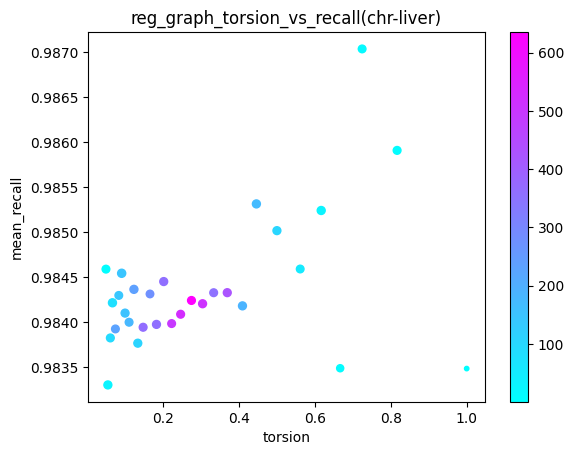

In [774]:
#For each possible weight of a fingerprint, plot average performance by score
import numpy
from numpy import exp
score = "recall"
weight = test_variables["x"]

averages = {score:[], weight: [], "std": [], "size":[]}

next_start = 0
for i in arange(0,1, 0.01):
    selection = df.loc[(df[weight]>next_start) & (df[weight]< (next_start + exp(-10)*exp(10*i)))]
    next_start = (next_start + exp(-10)*exp(10*i))
    selection_weight = selection[weight]
    selection_score = selection[f"mean_test_{score}"]
    if len(selection) > 0:
        avg_weight = mean(selection_weight)
        avg_score = mean(selection_score)
        averages[score].append(avg_score)
        averages[weight].append(avg_weight)
        averages["std"].append(numpy.std(selection_score))
        averages["size"].append(len(selection))

avg_df = pd.DataFrame(averages)

#Color bar will show how many data points from the main data frame contribute to each plotted point 
#to demonstrate some estimate of confidence
plt.scatter(x = avg_df[weight], y = avg_df[score], c = avg_df["size"], cmap = "cool", s = 5000*avg_df["std"]+10)
plt.colorbar()
plt.xlabel(weight)
plt.ylabel("mean_"+score)
title = f"reg_graph_{weight}_vs_{score}({endpoint})"
plt.title(title)
# plt.savefig(f"../references/full_print_results/{endpoint}/reg3_graphs/{title}.png")
plt.show()

### Full Scatter Graph

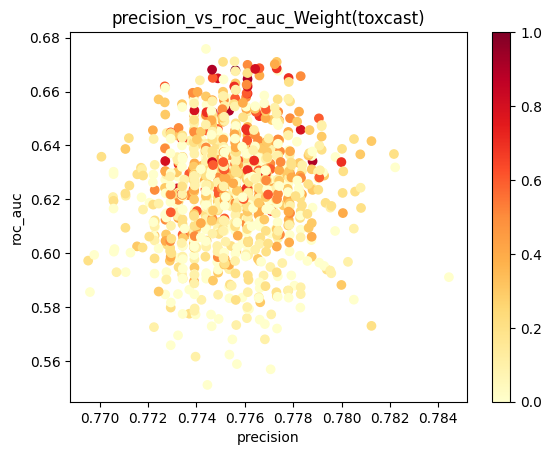

In [880]:
#Multi-scores
multi_variables = {"x":"precision", "y":"roc_auc", "c":"toxcast"}
plt.scatter(x = df[f"mean_test_{multi_variables["x"]}"], y=df[f"mean_test_{multi_variables["y"]}"], c= df[multi_variables["c"]], cmap = "YlOrRd")
plt.colorbar()
title = f"{multi_variables["x"]}_vs_{multi_variables["y"]}_Weight({multi_variables["c"]})"
plt.title(title)
plt.xlabel(multi_variables["x"])
plt.ylabel(multi_variables["y"])
plt.savefig(f"../references/full_print_results/{endpoint}/multi-scores/{title}_scatter.png")
plt.show()

# Data Analysis for Long-Form Results

In [17]:
import pandas as pd

score_df = pd.read_csv("../references/tp_tor_mor/prelim_results+tc_df.csv")
score_df["weights"] = [ [int(score_df["weights"][i][1]), int(score_df["weights"][i][4]), int(score_df["weights"][i][7]), int(score_df["weights"][i][10])] for i in range(0, len(score_df["weights"]))]
score_df.head()

,weights,TP,TN,FP,FN,accuracy,precision,recall
0,"[0, 0, 0, 1]",336,18,88,26,0.756410,0.792453,0.928177
1,"[0, 0, 1, 0]",331,17,89,31,0.743590,0.788095,0.914365
2,"[0, 0, 1, 1]",336,13,93,26,0.745726,0.783217,0.928177
3,"[0, 0, 1, 2]",339,12,94,23,0.750000,0.782910,0.936464
4,"[0, 0, 2, 1]",335,14,92,27,0.745726,0.784543,0.925414


In [32]:
#Calculate percentage contributions from the weights, as these are often more intuitive
morgan_weight = [score_df["weights"][i][1] for i in range(0,len(score_df["weights"]))]
toxprint_weight = [score_df["weights"][i][0] for i in range(0,len(score_df["weights"]))]
torsion_weight = [score_df["weights"][i][2] for i in range(0,len(score_df["weights"]))]
toxcast_weight = [score_df["weights"][i][3] for i in range(0,len(score_df["weights"]))]

score_df["morgan"] = [morgan_weight[i]/sum(score_df["weights"][i]) for i in range(0,len(morgan_weight))]
score_df["toxprint"] = [toxprint_weight[i]/sum(score_df["weights"][i]) for i in range(0,len(toxprint_weight))]
score_df["torsion"] = [torsion_weight[i]/sum(score_df["weights"][i]) for i in range(0,len(torsion_weight))]
score_df["toxcast"] = [toxcast_weight[i]/sum(score_df["weights"][i]) for i in range(0,len(toxcast_weight))]

In [33]:
#Check the DataFrame
score_df.head()

,weights,TP,TN,FP,FN,accuracy,precision,recall,morgan,toxprint,torsion,toxcast
0,"[0, 0, 0, 1]",336,18,88,26,0.756410,0.792453,0.928177,0.0,0.0,0.000000,1.000000
1,"[0, 0, 1, 0]",331,17,89,31,0.743590,0.788095,0.914365,0.0,0.0,1.000000,0.000000
2,"[0, 0, 1, 1]",336,13,93,26,0.745726,0.783217,0.928177,0.0,0.0,0.500000,0.500000
3,"[0, 0, 1, 2]",339,12,94,23,0.750000,0.782910,0.936464,0.0,0.0,0.333333,0.666667
4,"[0, 0, 2, 1]",335,14,92,27,0.745726,0.784543,0.925414,0.0,0.0,0.666667,0.333333


In [34]:
#Obtain best combination for accuracy
score_df.loc[score_df["accuracy"]==max(score_df["accuracy"])]

,weights,TP,TN,FP,FN,accuracy,precision,recall,morgan,toxprint,torsion,toxcast
22,"[1, 0, 1, 0]",344,16,90,18,0.769231,0.792627,0.950276,0.0,0.5,0.5,0.0


In [35]:
#Obtain best combination for precision
score_df.loc[score_df["precision"]==max(score_df["precision"])]

,weights,TP,TN,FP,FN,accuracy,precision,recall,morgan,toxprint,torsion,toxcast
50,"[2, 0, 2, 1]",341,17,89,21,0.764957,0.793023,0.941989,0.0,0.4,0.4,0.2


In [36]:
#Obtain best combination for recall
score_df.loc[score_df["recall"]==max(score_df["recall"])]

,weights,TP,TN,FP,FN,accuracy,precision,recall,morgan,toxprint,torsion,toxcast
19,"[1, 0, 0, 0]",345,11,95,17,0.760684,0.784091,0.953039,0.0,1.0,0.0,0.0


In [37]:
#Obtain best combination for not getting false positives
score_df.loc[score_df["FP"]==min(score_df["FP"])]

,weights,TP,TN,FP,FN,accuracy,precision,recall,morgan,toxprint,torsion,toxcast
0,"[0, 0, 0, 1]",336,18,88,26,0.75641,0.792453,0.928177,0.0,0.0,0.0,1.0
27,"[1, 0, 2, 2]",336,18,88,26,0.75641,0.792453,0.928177,0.0,0.2,0.4,0.4


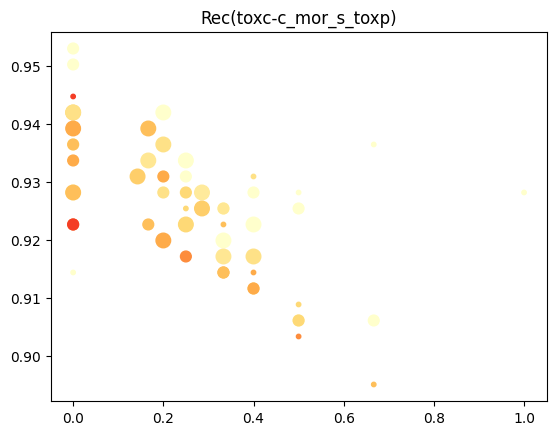

In [38]:
import matplotlib.pyplot as plt

#View and save results as scatterplot to analyze for trends. Note that most relations do not 
# appear to be linear, so such a regression may not be the best choice
plt.scatter(x = score_df["toxcast"], y= score_df["recall"], c= score_df["morgan"], cmap = "YlOrRd", s = [i*50+10 for i in toxprint_weight])
title = "Rec(toxc-c_mor_s_toxp)"
plt.title(title)
# plt.savefig(f"../references/tp_tor_mor/91test{title}percents_scatter.png")
plt.show()